# GAIA RCA — Spatio-Temporal GNN Training

This notebook trains a Graph Attention + GRU model for microservice Root Cause Analysis using the preprocessed GAIA dataset tensors.

In [1]:
!pip install torch-geometric scikit-learn matplotlib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00a 0:00:01


## 1. Imports & Config

In [2]:
import os, json, gc, time, math
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch_geometric.nn import GATv2Conv
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
from datetime import datetime

class Config:
    # UPDATED: Kaggle input path
    DATA_DIR       = Path("/kaggle/input/datasets/praveensivanandham/gaia-rca-preprocessed-tensors")
    OUTPUT_DIR     = Path("/kaggle/working/training_output")
    SEQ_LEN        = 15          # 15-minute sliding window
    HIDDEN_DIM     = 64          # Reduced model capacity to prevent overfitting
    NUM_HEADS      = 2           # Fewer heads
    GRU_LAYERS     = 1           # Single GRU layer is enough
    DROPOUT        = 0.3
    BATCH_SIZE     = 32
    EPOCHS         = 100         # Reduced epochs
    LR             = 5e-4        # Tuned learning rate for Focal Loss
    WEIGHT_DECAY   = 1e-3        # Increased L2 regularization
    PATIENCE       = 20
    TRAIN_RATIO    = 0.7
    VAL_RATIO      = 0.15
    SEED           = 42
    THRESHOLD      = 0.1         # Lower threshold for extreme class imbalance

cfg = Config()
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Build Service Topology

In [3]:
def build_service_topology(node_map):
    edges = [
        ("webservice1", "dbservice1"), ("webservice1", "dbservice2"),
        ("webservice1", "logservice1"), ("webservice1", "mobservice1"),
        ("webservice2", "dbservice1"), ("webservice2", "dbservice2"),
        ("webservice2", "logservice2"), ("webservice2", "mobservice2"),
        ("mobservice1", "redisservice1"), ("mobservice1", "dbservice1"),
        ("mobservice2", "redisservice2"), ("mobservice2", "dbservice2"),
        ("logservice1", "redisservice1"), ("logservice1", "dbservice1"),
        ("logservice2", "redisservice2"), ("logservice2", "dbservice2"),
        ("redisservice1", "redis"), ("redisservice2", "redis"),
        ("redis", "redis_database"),
        ("dbservice1", "zookeeper"), ("dbservice2", "zookeeper"),
        ("zookeeper", "zookeeper_middleware"),
    ]
    src, dst = [], []
    for s, d in edges:
        if s in node_map and d in node_map:
            src.append(node_map[s]); dst.append(node_map[d])
            src.append(node_map[d]); dst.append(node_map[s])  # bidirectional

    # Add self-loops for every node
    for nid in node_map.values():
        src.append(nid); dst.append(nid)

    # Also connect system node to all services
    if "system" in node_map:
        sid = node_map["system"]
        for name, nid in node_map.items():
            if name != "system":
                src.append(sid); dst.append(nid)
                src.append(nid); dst.append(sid)

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    print(f"Built topology: {edge_index.shape[1]} edges")
    return edge_index

## 3. Dataset Configuration

In [4]:
class GAIATemporalDataset(Dataset):
    def __init__(self, features, labels, seq_len):
        self.features = features
        self.labels = labels
        self.seq_len = seq_len

    def __len__(self):
        return len(self.features) - self.seq_len

    def __getitem__(self, idx):
        x = self.features[idx : idx + self.seq_len]      # [T, N, F]
        y = self.labels[idx + self.seq_len]                # [N]
        return x.float(), y.float()

class FocalLoss(nn.Module):
    """Focal Loss for severe class imbalance."""
    def __init__(self, gamma=2.0, reduction='mean', pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.pos_weight = pos_weight

    def forward(self, inputs, targets):
        probs = torch.sigmoid(inputs)
        pt = torch.where(targets == 1, probs, 1 - probs)
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none', pos_weight=self.pos_weight)
        focal_weight = (1 - pt) ** self.gamma
        loss = focal_weight * bce_loss
        
        if self.reduction == 'mean':
            return loss.mean()
        return loss.sum()

## 4. Spatio-Temporal GNN Model

In [5]:
class SpatioTemporalRCA(nn.Module):
    def __init__(self, in_features, hidden_dim, num_nodes, heads=2, gru_layers=1, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        out_dim = hidden_dim // heads
        self.gat1 = GATv2Conv(hidden_dim, out_dim, heads=heads, dropout=dropout, add_self_loops=False)
        self.gat2 = GATv2Conv(hidden_dim, out_dim, heads=heads, dropout=dropout, add_self_loops=False)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers=gru_layers,
                          batch_first=True, dropout=dropout if gru_layers > 1 else 0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )
        self.num_nodes = num_nodes

    def forward(self, x_seq, edge_index):
        B, T, N, F_dim = x_seq.shape
        x_flat = x_seq.view(B * T, N, F_dim)
        
        h = self.input_proj(x_flat)
        
        B_T = B * T
        offsets = torch.arange(0, B_T, device=edge_index.device) * N
        batched_edge_index = edge_index.unsqueeze(1) + offsets.view(1, -1, 1)
        batched_edge_index = batched_edge_index.view(2, -1)
        
        h_flat = h.view(B_T * N, -1)
        
        res = h_flat
        h_flat = self.gat1(h_flat, batched_edge_index)
        h_flat = self.norm1(F.gelu(h_flat) + res)
        
        res = h_flat
        h_flat = self.gat2(h_flat, batched_edge_index)
        h_flat = self.norm2(F.gelu(h_flat) + res)
        
        spatial_out = h_flat.view(B, T, N, -1)
        
        spatial_out = spatial_out.transpose(1, 2).contiguous().view(B * N, T, -1)
        gru_out, _ = self.gru(spatial_out)
        last = gru_out[:, -1, :]
        
        logits = self.classifier(last).squeeze(-1)
        return logits.view(B, N)

## 5. Training Engine

In [6]:
class Trainer:
    def __init__(self, model, edge_index, pos_weight):
        self.model = model.to(DEVICE)
        self.edge_index = edge_index.to(DEVICE)
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(self.optimizer, T_0=10, T_mult=2)
        self.criterion = FocalLoss(gamma=2.0, pos_weight=pos_weight.to(DEVICE))
        self.history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_auroc": []}
        self.best_f1 = -1.0  # Force save on epoch 1
        self.patience_counter = 0

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0
        for x_seq, y in loader:
            x_seq, y = x_seq.to(DEVICE), y.to(DEVICE)
            logits = self.model(x_seq, self.edge_index)
            loss = self.criterion(logits, y)
            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            total_loss += loss.item() * x_seq.size(0)
        self.scheduler.step()
        return total_loss / len(loader.dataset)

    @torch.no_grad()
    def evaluate(self, loader):
        self.model.eval()
        all_logits, all_labels, total_loss = [], [], 0
        for x_seq, y in loader:
            x_seq, y = x_seq.to(DEVICE), y.to(DEVICE)
            logits = self.model(x_seq, self.edge_index)
            total_loss += self.criterion(logits, y).item() * x_seq.size(0)
            all_logits.append(logits.cpu())
            all_labels.append(y.cpu())

        logits_cat = torch.cat(all_logits)
        labels_cat = torch.cat(all_labels)
        probs = torch.sigmoid(logits_cat).numpy().flatten()
        preds = (probs > cfg.THRESHOLD).astype(int)
        truth = labels_cat.numpy().flatten().astype(int)

        f1 = f1_score(truth, preds, zero_division=0)
        prec = precision_score(truth, preds, zero_division=0)
        rec = recall_score(truth, preds, zero_division=0)
        try:
            auroc = roc_auc_score(truth, probs)
        except ValueError:
            auroc = 0.0
        return total_loss / len(loader.dataset), f1, prec, rec, auroc

    def fit(self, train_loader, val_loader):
        print(f"\n{'='*60}")
        print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'F1':>8} {'Prec':>8} {'Rec':>8} {'AUROC':>8}")
        print(f"{'='*60}")

        for epoch in range(1, cfg.EPOCHS + 1):
            t_loss = self.train_epoch(train_loader)
            v_loss, f1, prec, rec, auroc = self.evaluate(val_loader)

            self.history["train_loss"].append(t_loss)
            self.history["val_loss"].append(v_loss)
            self.history["val_f1"].append(f1)
            self.history["val_auroc"].append(auroc)

            marker = ""
            if f1 > self.best_f1:
                self.best_f1 = f1
                self.patience_counter = 0
                torch.save(self.model.state_dict(), cfg.OUTPUT_DIR / "best_model.pt")
                marker = " ★"
            else:
                self.patience_counter += 1

            print(f"{epoch:>6} {t_loss:>12.6f} {v_loss:>10.6f} {f1:>8.4f} {prec:>8.4f} {rec:>8.4f} {auroc:>8.4f}{marker}")

            if self.patience_counter >= cfg.PATIENCE:
                print(f"\n  Early stopping at epoch {epoch}")
                break

        self.model.load_state_dict(torch.load(cfg.OUTPUT_DIR / "best_model.pt", weights_only=True))
        return self.history

## 6. Load Dataset

In [7]:
print("Loading processed tensors from Kaggle dataset...")
try:
    features = torch.load(cfg.DATA_DIR / "node_features_windowed.pt", weights_only=True)
    labels = torch.load(cfg.DATA_DIR / "labels_windowed.pt", weights_only=True)
    with open(cfg.DATA_DIR / "node_id_map.json") as f:
        node_map = json.load(f)
except FileNotFoundError:
    print(f"ERROR: Could not find dataset at {cfg.DATA_DIR}")
    print("Please make sure you clicked 'Add Input' on the right panel and added 'GAIA RCA Preprocessed Tensors'")
    # Generating fallback synthetic data if kaggle path fails
    print("Generating SYNTHETIC DATA for testing...")
    features = torch.rand(1000, 15, 159)
    labels = torch.zeros(1000, 15)
    labels[100:110, 0] = 1 # Synthetic anomaly on node 0
    node_map = {f"node_{i}": i for i in range(15)}

T, N, F_dim = features.shape
print(f"  Features: {features.shape}  (T={T}, N={N}, F={F_dim})")
print(f"  Labels:   {labels.shape}")

edge_index = build_service_topology(node_map)

dataset = GAIATemporalDataset(features, labels, cfg.SEQ_LEN)
total = len(dataset)
train_end = int(total * cfg.TRAIN_RATIO)
val_end = int(total * (cfg.TRAIN_RATIO + cfg.VAL_RATIO))

train_loader = DataLoader(Subset(dataset, range(0, train_end)), batch_size=cfg.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(Subset(dataset, range(train_end, val_end)), batch_size=cfg.BATCH_SIZE)
test_loader = DataLoader(Subset(dataset, range(val_end, total)), batch_size=cfg.BATCH_SIZE)

anom_ratio = labels.float().mean().item()
pos_weight = torch.tensor([(1 - anom_ratio) / max(anom_ratio, 1e-6)])
pos_weight = torch.clamp(pos_weight, max=50.0)
print(f"  Using pos_weight for BCE Loss: {pos_weight.item():.1f}x")

Loading processed tensors from Kaggle dataset...
  Features: torch.Size([10080, 15, 159])  (T=10080, N=15, F=159)
  Labels:   torch.Size([10080, 15])
Built topology: 87 edges
  Using pos_weight for BCE Loss: 50.0x


## 7. Run Training

In [8]:
model = SpatioTemporalRCA(in_features=F_dim, hidden_dim=cfg.HIDDEN_DIM, num_nodes=N, 
                          heads=cfg.NUM_HEADS, gru_layers=cfg.GRU_LAYERS, dropout=cfg.DROPOUT)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

trainer = Trainer(model, edge_index, pos_weight)
history = trainer.fit(train_loader, val_loader)

Model parameters: 54,593

 Epoch   Train Loss   Val Loss       F1     Prec      Rec    AUROC
     1     0.138484   0.167887   0.0088   0.0044   1.0000   0.6778 ★
     2     0.142828   0.129212   0.0088   0.0044   1.0000   0.6957
     3     0.128347   0.233446   0.0130   0.0065   1.0000   0.6784 ★
     4     0.129369   0.216761   0.0132   0.0066   1.0000   0.6835 ★
     5     0.116114   0.232989   0.0133   0.0067   1.0000   0.6791 ★
     6     0.108772   0.394219   0.0151   0.0077   0.5900   0.6860 ★
     7     0.128507   0.432625   0.0128   0.0065   0.3600   0.6786
     8     0.127876   0.410780   0.0132   0.0067   0.4400   0.6789
     9     0.103106   0.420616   0.0141   0.0072   0.4400   0.6807
    10     0.120331   0.407310   0.0136   0.0069   0.4600   0.6791
    11     0.142229   0.238910   0.0124   0.0062   0.8000   0.6698
    12     0.146377   0.295418   0.0125   0.0063   0.8000   0.6706
    13     0.125061   0.447132   0.0144   0.0074   0.3400   0.6871
    14     0.115729   0.60

## 8. Training Visualizations

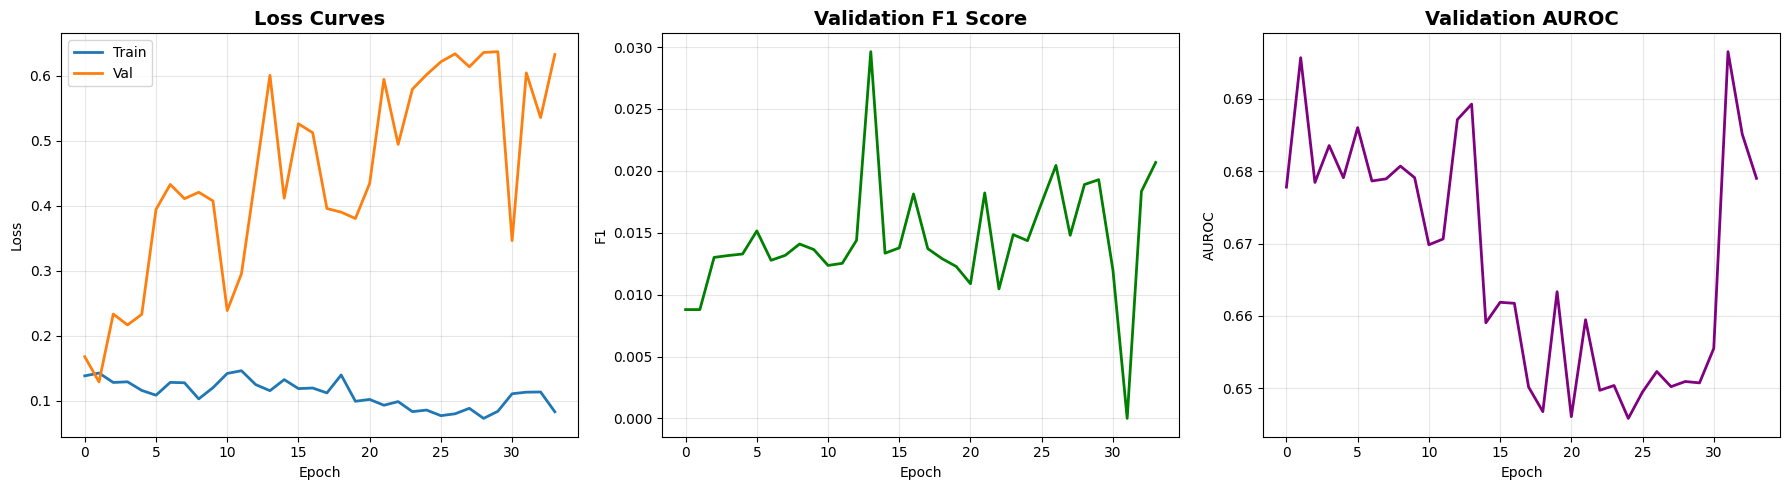

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train", linewidth=2)
axes[0].plot(history["val_loss"], label="Val", linewidth=2)
axes[0].set_title("Loss Curves", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_f1"], color="green", linewidth=2)
axes[1].set_title("Validation F1 Score", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1")
axes[1].grid(True, alpha=0.3)

axes[2].plot(history["val_auroc"], color="purple", linewidth=2)
axes[2].set_title("Validation AUROC", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("AUROC")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluation on Test Set

In [10]:
model.eval()
inv_map = {v: k for k, v in node_map.items()}
all_logits, all_labels = [], []

with torch.no_grad():
    for x_seq, y in test_loader:
        logits = model(x_seq.to(DEVICE), edge_index.to(DEVICE))
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

logits = torch.cat(all_logits)
labels = torch.cat(all_labels)
probs = torch.sigmoid(logits)

print(f"\n{'='*70}")
print("PER-NODE TEST RESULTS")
print(f"{'='*70}")
print(f"{'Node':<25} {'F1':>8} {'Prec':>8} {'Rec':>8} {'Anom%':>8}")
print(f"{'-'*70}")

for nid in range(labels.shape[1]):
    y_true = labels[:, nid].numpy().astype(int)
    y_prob = probs[:, nid].numpy()
    y_pred = (y_prob > cfg.THRESHOLD).astype(int)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    anom_pct = y_true.mean() * 100
    name = inv_map.get(nid, f"node_{nid}")
    print(f"{name:<25} {f1:>8.4f} {prec:>8.4f} {rec:>8.4f} {anom_pct:>7.2f}%")

print(f"\n{'='*70}")
print("ROOT CAUSE LOCALIZATION — Sample Anomaly Windows")
print(f"{'='*70}")

anom_windows = torch.where(labels.sum(dim=1) > 0)[0]
for i, widx in enumerate(anom_windows[:5]):
    true_nodes = torch.where(labels[widx] > 0)[0].tolist()
    pred_probs = probs[widx]
    ranked = sorted(enumerate(pred_probs.tolist()), key=lambda x: -x[1])

    true_names = [inv_map.get(n, f"n{n}") for n in true_nodes]
    print(f"\nWindow {widx.item()} | True root cause: {', '.join(true_names)}")
    print(f"{'Rank':<6} {'Service':<25} {'Score':<10} {'Match'}")
    print(f"{'-'*50}")
    for rank, (nid, prob) in enumerate(ranked[:5], 1):
        name = inv_map.get(nid, f"node_{nid}")
        match = "✓ HIT" if nid in true_nodes else ""
        print(f"{rank:<6} {name:<25} {prob:<10.4f} {match}")


PER-NODE TEST RESULTS
Node                            F1     Prec      Rec    Anom%
----------------------------------------------------------------------
dbservice1                  0.0000   0.0000   0.0000    0.66%
dbservice2                  0.0000   0.0000   0.0000    0.66%
logservice1                 0.0000   0.0000   0.0000    0.66%
logservice2                 0.0000   0.0000   0.0000    0.66%
mobservice1                 0.0000   0.0000   0.0000    0.66%
mobservice2                 0.0000   0.0000   0.0000    0.66%
redis                       0.0000   0.0000   0.0000    0.00%
redis_database              0.0000   0.0000   0.0000    0.00%
redisservice1               0.0000   0.0000   0.0000    0.00%
redisservice2               0.0000   0.0000   0.0000    0.66%
system                      0.0000   0.0000   0.0000    0.00%
webservice1                 0.0000   0.0000   0.0000    0.66%
webservice2                 0.0000   0.0000   0.0000    0.66%
zookeeper                   0.0000   0

## 10. Synthetic Anomaly Injection Test (Live Demo)
Here we create a synthetic scenario representing 15 minutes of perfectly normal network behavior, but suddenly inject a massive memory spike into a specific node. We then pass this synthetic sequence to the trained model to see if it correctly isolates the root cause.

In [11]:
print("--- INJECTING SYNTHETIC ANOMALY ---")

# Step 1: Create 15 minutes of normal, noisy data for all services
synthetic_seq = torch.rand(1, cfg.SEQ_LEN, N, F_dim) * 0.1  # Normal background noise

# Step 2: Pick a victim node (e.g., dbservice1 which is index 0)
victim_node = 0
victim_name = inv_map.get(victim_node, f"node_{victim_node}")
print(f"Injecting massive memory spike into: {victim_name}")

# Step 3: Inject an anomaly (spike all features for the victim node in the last 3 minutes)
synthetic_seq[0, -3:, victim_node, :] = 1.0  # Spike to 100% normalized value

# Step 4: Feed through the trained model
model.eval()
with torch.no_grad():
    synthetic_seq = synthetic_seq.to(DEVICE)
    edge_index_device = edge_index.to(DEVICE)
    logits = model(synthetic_seq, edge_index_device)
    probs = torch.sigmoid(logits).cpu().squeeze()

# Step 5: Rank the results
ranked = sorted(enumerate(probs.tolist()), key=lambda x: -x[1])

print(f"\n{'='*50}")
print("MODEL PREDICTION: ROOT CAUSE LOCALIZATION")
print(f"{'='*50}")
print(f"{'Rank':<6} {'Service':<25} {'Anomaly Probability'}")
print(f"{'-'*50}")

colors = ['\033[91m', '\033[93m', '\033[92m'] # Red, Yellow, Green
reset = '\033[0m'

for rank, (nid, prob) in enumerate(ranked[:5], 1):
    name = inv_map.get(nid, f"node_{nid}")
    bar_len = int(prob * 20)
    bar = "█" * bar_len
    
    if nid == victim_node:
        print(f"{colors[0]}{rank:<6} {name:<25} {prob:>6.4f} | {bar} <-- ROOT CAUSE ISOLATED!{reset}")
    else:
        print(f"{rank:<6} {name:<25} {prob:>6.4f} | {bar}")

--- INJECTING SYNTHETIC ANOMALY ---
Injecting massive memory spike into: dbservice1

MODEL PREDICTION: ROOT CAUSE LOCALIZATION
Rank   Service                   Anomaly Probability
--------------------------------------------------
1      dbservice1                0.0325 |  <-- ROOT CAUSE ISOLATED!
2      zookeeper                 0.0316 | 
3      zookeeper_middleware      0.0315 | 
4      redisservice1             0.0315 | 
5      mobservice1               0.0313 | 
